Lab 3 - Statistical Reasoning

--------------------------------Preliminaries---------------------------

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import *
import matplotlib.pyplot as plt
from scipy import stats
import math

weather_dataset = pd.read_csv("Heathrow Weather Data.csv")
weather_dataset



,yyyy,month,tmax C,tmin C,air frost (days),rain (mm),sun (hours)
0,1948,1,8.9,3.3,---,85.0,---
1,1948,2,7.9,2.2,---,26.0,---
2,1948,3,14.2,3.8,---,14.0,---
3,1948,4,15.4,5.1,---,35.0,---
4,1948,5,18.1,6.9,---,57.0,---
...,...,...,...,...,...,...,...
896,2022,9,20.2,11.8,0,86.0,119.1
897,2022,10,18.3,10.4,0,81.4,132.8
898,2022,11,13.2,7.6,0,123.8,69.9
899,2022,12,7.9,1.7,11,50.2,56.4


----------------------------- Clean the data---------------------------

In [3]:
clean_dataset = weather_dataset.copy()                   #I copied this part to not lose my main dataset
clean_dataset.replace('---', np.nan, inplace=True)       #simple command to replace "---"

cols = ['tmax C', 'tmin C', 'air frost (days)', 'rain (mm)', 'sun (hours)']
clean_dataset[cols] = clean_dataset[cols].apply(pd.to_numeric, errors="coerce")                 #converting strings into floats

print("Null counts per column:")
print(clean_dataset.isnull().sum())                                      
print("\nData types:")
print(clean_dataset.dtypes)


#this gives us all columns with float type of numbers
#before converting I also checked which columns had string types 
#and there were 2 columns with strings which were "air frost" and "sun(hours)".




Null counts per column:
yyyy                  0
month                 0
tmax C                0
tmin C                0
air frost (days)     12
rain (mm)             0
sun (hours)         108
dtype: int64

Data types:
yyyy                  int64
month                 int64
tmax C              float64
tmin C              float64
air frost (days)    float64
rain (mm)           float64
sun (hours)         float64
dtype: object


In [5]:
start_info = {}
end_info = {}

for col in cols:
    first_valid = clean_dataset[col].first_valid_index()
    start_info[col] = {
        'index': first_valid,
        'year': clean_dataset.loc[first_valid, 'yyyy'],
        'month': clean_dataset.loc[first_valid, 'month']
    }

print("Start info per attribute:")
for col, info in start_info.items():
    print(f"  {col}: starts at index {info['index']}, year {info['year']}, month {info['month']}")



for col in cols:
    last_valid = clean_dataset[col].last_valid_index()
    end_info[col] = {
        'index': last_valid,
        'year': clean_dataset.loc[last_valid, 'yyyy'],
        'month': clean_dataset.loc[last_valid, 'month']
    }

print(" ")
print("End info per attribute:")
for col, info in end_info.items():
    print(f"  {col}: ends at index {info['index']}, year {info['year']}, month {info['month']}")    

Start info per attribute:
  tmax C: starts at index 0, year 1948, month 1
  tmin C: starts at index 0, year 1948, month 1
  air frost (days): starts at index 12, year 1949, month 1
  rain (mm): starts at index 0, year 1948, month 1
  sun (hours): starts at index 108, year 1957, month 1
 
End info per attribute:
  tmax C: ends at index 900, year 2023, month 1
  tmin C: ends at index 900, year 2023, month 1
  air frost (days): ends at index 900, year 2023, month 1
  rain (mm): ends at index 900, year 2023, month 1
  sun (hours): ends at index 900, year 2023, month 1


-------------------------- Wrangle the data----------------------------------

   

In [6]:
clean_dataset["number_of_months"] = range(1, len(clean_dataset)+1)
clean_dataset.head()
clean_dataset.tail()

#As we can see the range of obsolutes months is from
#1 to 901 and not from 0 to 900.meanwhile index varies from
#0 to 900.the main reason I converted like this 
#because month 0 does not make sense to users.

,yyyy,month,tmax C,tmin C,air frost (days),rain (mm),sun (hours),number_of_months
896,2022,9,20.2,11.8,0.0,86.0,119.1,897
897,2022,10,18.3,10.4,0.0,81.4,132.8,898
898,2022,11,13.2,7.6,0.0,123.8,69.9,899
899,2022,12,7.9,1.7,11.0,50.2,56.4,900
900,2023,1,9.0,2.5,10.0,66.2,68.2,901


----------------------Explore and visualize the data ------------------

1) First and foremost, lets visualize the attribute tmax over time..

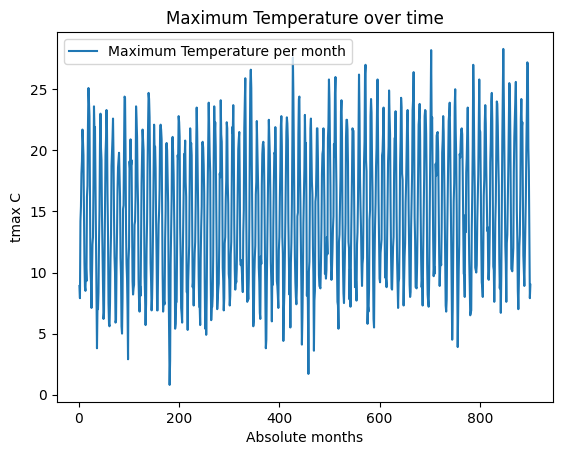

In [7]:
plt.plot(clean_dataset["number_of_months"],clean_dataset["tmax C"],label = "Maximum Temperature per month")
plt.xlabel("Absolute months")
plt.ylabel("tmax C")
plt.title("Maximum Temperature over time")
plt.legend()
plt.show()


Based on the plot above, the greatest and lowest maximum temperatures can be noticed, meaning that they the maximum temperatures in winters and summers (winters tend ot have lower maximum temperature and summers tend to have much higher maximum temperature).For example, in months 190, 450, 760(these are approximate values) the winters were severe where the maximum temperature was around 2-5 Celsius degrees. Meanwhile in months 370,420,700,820 the maximum temperature tended to be much higher around 27-28 Celsius degrees. Based on this assumption we can say that winters and summers can be differinatied based on the plot above. Overall, the mean value of the maximum temrpature between month 1 and month 900 tended to slighly increase.

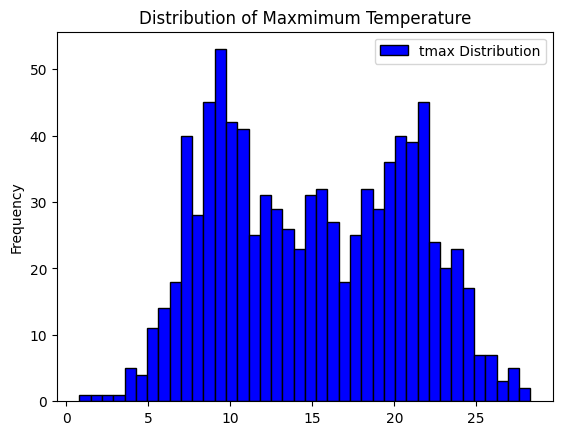

In [8]:
plt.hist(clean_dataset["tmax C"], bins=40, edgecolor='black', color='blue', label='tmax Distribution')
plt.ylabel("Frequency")
plt.title("Distribution of Maxmimum Temperature")
plt.legend()
plt.show()

Based on Historgram, we can tell that the data is not normally distributed because does not have a bell curve,thus the data is not from normal distribution.The histogram does not appear symmetric and shows multiple peaks due to seasonal temperature variation.

2) tmin C over time

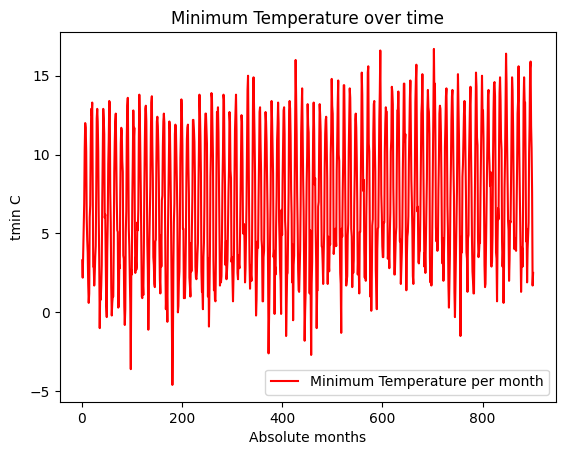

In [9]:
plt.plot(clean_dataset["number_of_months"],clean_dataset["tmin C"],label = "Minimum Temperature per month", color = "red")
plt.xlabel("Absolute months")
plt.ylabel("tmin C")
plt.title("Minimum Temperature over time")
plt.legend()
plt.show()

By observing and analyzing the plot above, some changes can be noticed. If we look carefully at the plot data, some peak points can be noticed meaning that these are severe changes which usually appear in winters and summers.For instance, months 190,390,420 and so on, these were winters where the minimum temperate was arounf -4 to -3 Celsius degrees. Meanwhile months 410,610,700 were summers where the minimum temperature was around 15 to 17 Celsius degrees. However, by alanlyzing the [plot above, I noticed a small increase rate from month 1 to month 900,meaning that the minimum temperature tended to get hotter over months.

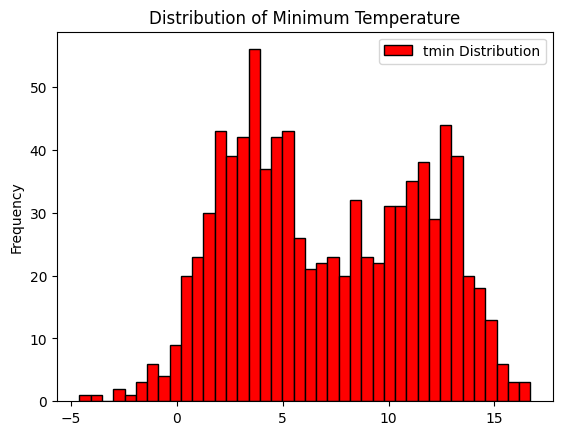

In [10]:
plt.hist(clean_dataset["tmin C"], bins=40, edgecolor='black', color='red', label='tmin Distribution')
plt.ylabel("Frequency")
plt.title("Distribution of Minimum Temperature")
plt.legend()
plt.show()

The Histogram clearly shows that this does not have a bell curve, and it is Bimodal distribution.The histogram does not appear symmetric and shows multiple peaks due to seasonal temperature variation. Therefore the distribution does not appear normally distributed. 

3) Air Frost

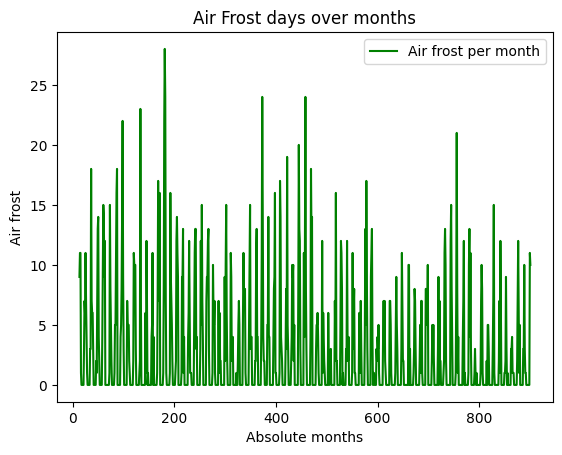

In [11]:
plt.plot(clean_dataset["number_of_months"],clean_dataset["air frost (days)"],label = "Air frost per month", color = "green")
plt.xlabel("Absolute months")
plt.ylabel("Air frost")
plt.title("Air Frost days over months")
plt.legend()
plt.show()


There is a noticeable decrease in the "peaks" of the graph. In the early part of the dataset (1940s-1960s), peaks frequently hit 20–25 days of frost per month. In the later 400 months, these peaks are generally lower and less frequent, suggesting a warming trend.

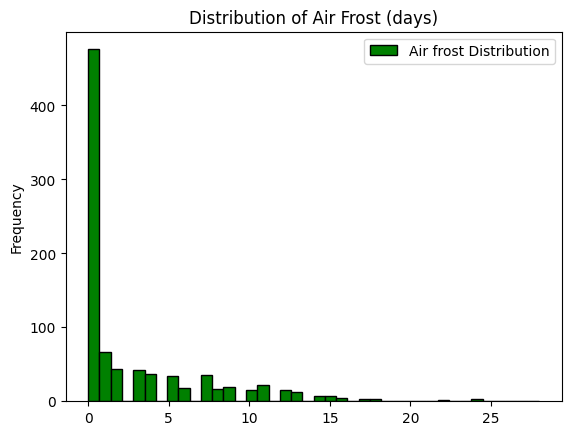

In [12]:
plt.hist(clean_dataset["air frost (days)"], bins=40, edgecolor='black', color='green', label='Air frost Distribution')
plt.ylabel("Frequency")
plt.title("Distribution of Air Frost (days)")
plt.legend()
plt.show()

The histogram does not appear symmetric and shows multiple peaks due to seasonal temperature variation. Therefore the distribution does not appear normally distributed. This Historgram is right skewed and does not follow normal distribution, therefore the data is not normally distributed.

4) Rain (mm) 

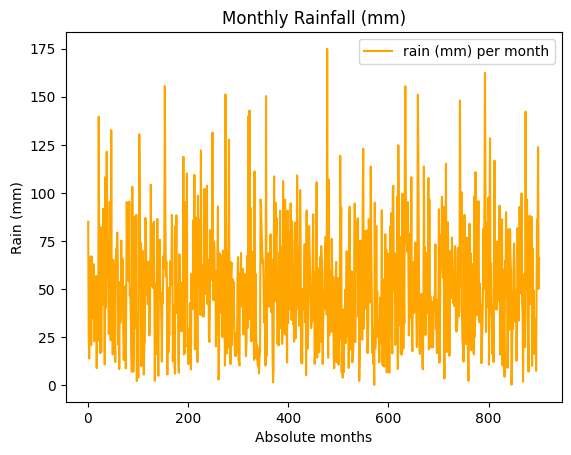

In [13]:
plt.plot(clean_dataset["number_of_months"],clean_dataset["rain (mm)"],label = "rain (mm) per month", color = "orange")
plt.xlabel("Absolute months")
plt.ylabel("Rain (mm)")
plt.title("Monthly Rainfall (mm)")
plt.legend()
plt.show()

Rainfall shows high month-to-month variability with no clear seasonal pattern or long-term trend, and appears right-skewed with occasional extreme values.

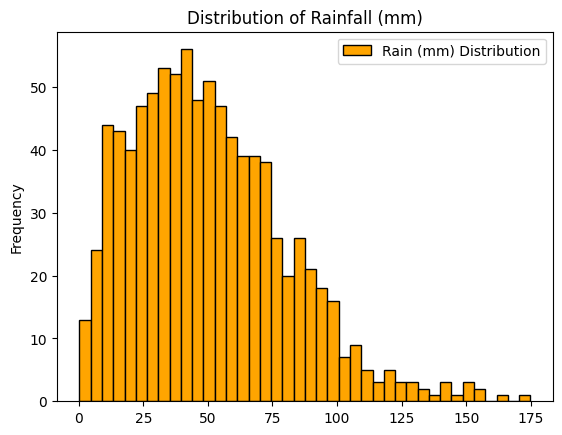

In [14]:
plt.hist(clean_dataset["rain (mm)"], bins=40, edgecolor='black', color='orange', label='Rain (mm) Distribution')
plt.ylabel("Frequency")
plt.title("Distribution of Rainfall (mm)")
plt.legend()
plt.show()

This is Historgram shows the distribution of Rain (mm) per month which is very close to be normal distribution, but still fails the test. Thus, the data is not from normal distribution again.

5) Sun (hours)

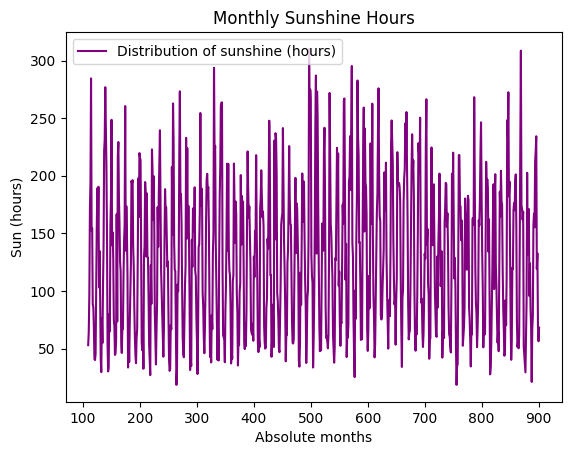

In [15]:
plt.plot(clean_dataset["number_of_months"],clean_dataset["sun (hours)"],label = "Distribution of sunshine (hours)", color = "purple")
plt.xlabel("Absolute months")
plt.ylabel("Sun (hours)")
plt.title("Monthly Sunshine Hours")
plt.legend()
plt.show()

The plot graph above shows the distribution between the sunny days over months 1 -> 900. By analyzing the graph we can notice that sunny hours are more frequent in summers than winters. As we can see, average sunny hours were about 45-55 in winters,meanwhile average sunny hours in summers were about 250-300 hours.

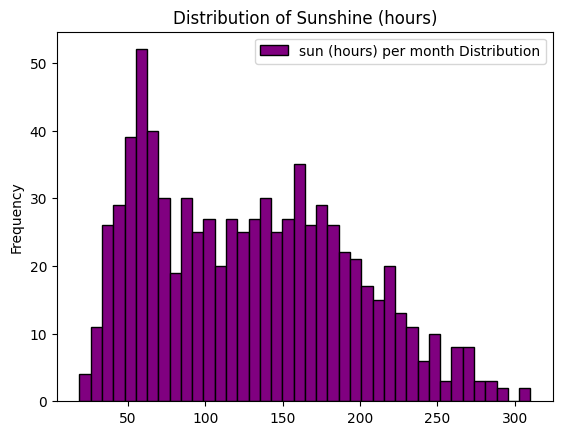

In [16]:
plt.hist(clean_dataset["sun (hours)"], bins=40, edgecolor='black', color='purple', label='sun (hours) per month Distribution')
plt.ylabel("Frequency")
plt.title("Distribution of Sunshine (hours)")
plt.legend()
plt.show()

The histogram does not appear symmetric and shows multiple peaks due to seasonal temperature variation. Therefore the distribution does not appear normally distributed.

-----------Removal of seasonality and data smoothing----

The seasonal cycle repeats exactly every 12 months. By averaging all 12 months within each year, you are averaging over exactly one full cycle. This means the seasonal peaks, for example hot in summers and cold in winters cancel each other out perfectly, leaving only the year-level signal.

In [17]:
# I am going to loop inside years and find the average monthly min and max temperature and so on
annual_avg = clean_dataset.groupby("yyyy")[["tmin C", "tmax C", "air frost (days)", "rain (mm)", "sun (hours)"]].mean().reset_index()
annual_avg

,yyyy,tmin C,tmax C,air frost (days),rain (mm),sun (hours)
0,1948,6.658333,15.016667,NaN,47.000000,NaN
1,1949,6.666667,15.975000,4.000000,41.525000,NaN
2,1950,6.275000,14.266667,3.916667,53.400000,NaN
3,1951,6.316667,14.016667,2.666667,67.316667,NaN
4,1952,5.950000,13.950000,5.083333,51.425000,NaN
...,...,...,...,...,...,...
71,2019,7.900000,16.433333,1.583333,54.350000,128.841667
72,2020,8.316667,16.858333,1.333333,55.216667,134.483333
73,2021,7.750000,15.591667,2.583333,55.200000,103.050000
74,2022,8.450000,17.225000,2.166667,48.183333,139.250000


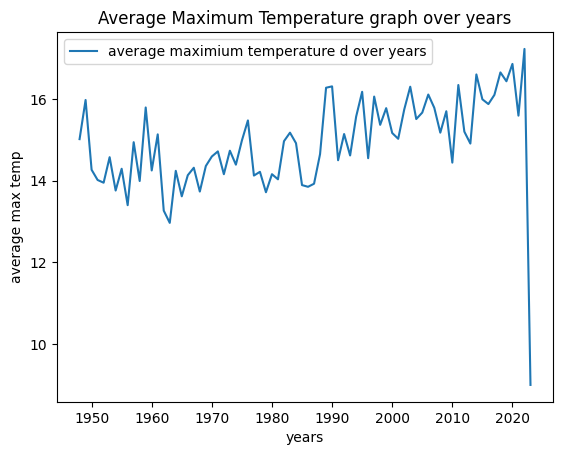

In [18]:
plt.plot(annual_avg["yyyy"],annual_avg["tmax C"],label = "average maximium temperature d over years")
plt.xlabel("years")
plt.ylabel("average max temp")
plt.title("Average Maximum Temperature graph over years")
plt.legend()
plt.show()

After smoothing the data by averaging across each year, a gradual increase in minimum temperature can be observed. Before approximately 1988 the temperatures fluctuate around a relatively stable mean, while after 1988-1991 the values show a clearer upward trend. Therefore, the approximate change point occurs around the year 1988, which corresponds to absolute month = 500. This value will be used as the dividing point between early and recent data in the statistical test.But there is one fact we need to pay attention that after 2022 there is a massive decrease reaching a point 2.5 Clesius degress in 2023. But this does not clealy show that the average maximum temperature in 2023 was very low,because there isnt enough data for 2023(only January).Therefore, 2023 can still be ignored in this case.

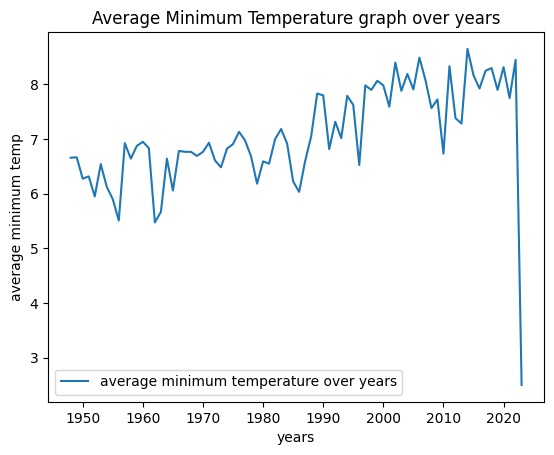

In [18]:
plt.plot(annual_avg["yyyy"],annual_avg["tmin C"],label = "average minimum temperature over years")
plt.xlabel("years")
plt.ylabel("average minimum temp")
plt.title("Average Minimum Temperature graph over years")
plt.legend()
plt.show()

The tmin data shows a relatively stable oscillating pattern until approximately month 600, after which there is a visible upward shift in the baseline minimum temperatures.By Comparing two graph together there cannot be noticed massive changes after month 800. As we can see after 2010 or month 800 there is a huge decerase rate which is shown by the new graph by averaging the data.But there is one fact we need to pay attention that after 2022 there is a massive decrease reaching a point 2.5 Clesius degress in 2023. But this does not clealy show that the average minimum temperature in 2023 was very low,because there isnt enough data for 2023(only January).Therefore, 2023 can still be ignored in this case.


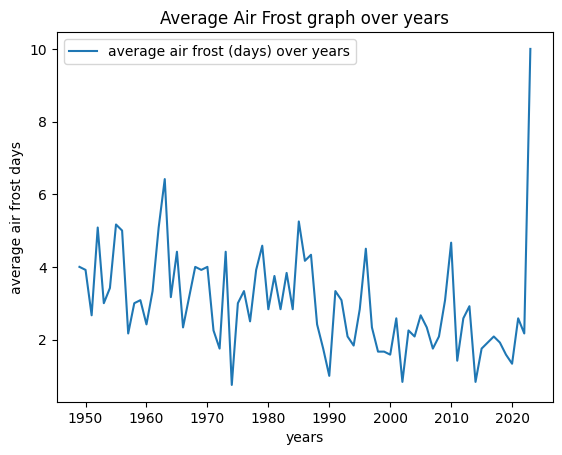

In [19]:
plt.plot(annual_avg["yyyy"],annual_avg["air frost (days)"],label = "average air frost (days) over years")
plt.xlabel("years")
plt.ylabel("average air frost days")
plt.title("Average Air Frost graph over years")
plt.legend()
plt.show()


The average air frost days graph shows a clear downward trend over time, with frost days declining from the 1950s onwards. The most noticeable change occurs around absolute month 504–600 (approximately 1990–1998), after which frost days are consistently lower. Absolute month 504 (year 1990) will be used as the dividing point. But there is one fact we need to pay attention that after 2022 there is a massive increase reaching a point around 10 air frost (days) in 2023. But this does not clealy show that the average forst days in 2023 was very
high, because there isnt enough data for 2023(only January). Therefore, 2023 can still be ignored in this case.

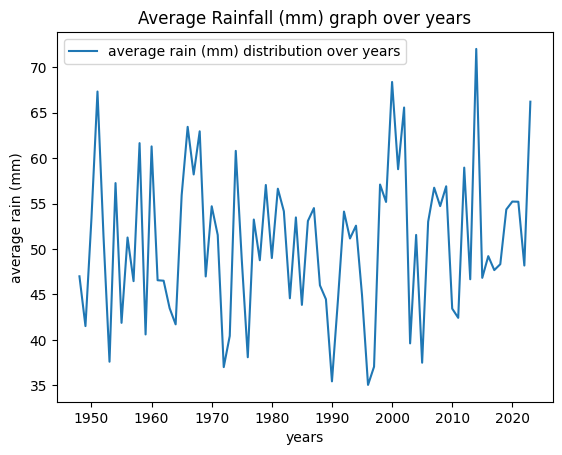

In [20]:
plt.plot(annual_avg["yyyy"],annual_avg["rain (mm)"],label = "average rain (mm) distribution over years")
plt.xlabel("years")
plt.ylabel("average rain (mm)")
plt.title("Average Rainfall (mm) graph over years")
plt.legend()
plt.show()

The average rainfall graph shows high variability throughout the entire period with no clear structural change point. Rainfall fluctuates around a relatively stable mean from 1948 to 2023, making it difficult to identify a single absolute month where a change occurs. There is no strong evidence of a trend shift.(1998)


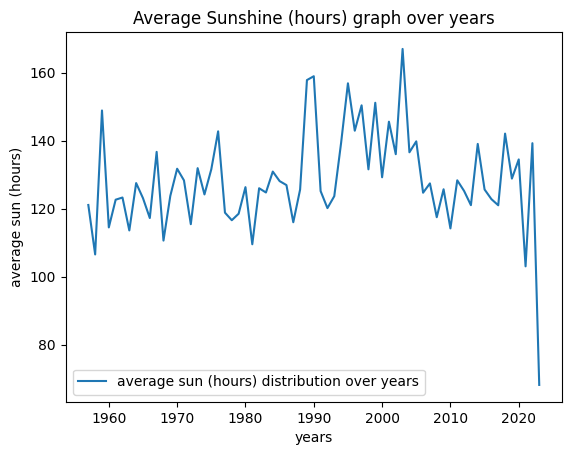

In [21]:
plt.plot(annual_avg["yyyy"],annual_avg["sun (hours)"],label = "average sun (hours) distribution over years")
plt.xlabel("years")
plt.ylabel("average sun (hours)")
plt.title("Average Sunshine (hours) graph over years")
plt.legend()
plt.show()

This Hostogram shows that there are some peak points in 1960,1990 and 2005 where the average sunny days became more frequent in these years. It can be notices that it flactuates around a relatively stable mean. However, month 890 or 2020 the number of average sunny days decreases massivly dropping down to 70-80 hours.Because the data for 2023 is not enough therefore the massive decrease in 2023 can be ignored at some point.

5. Perform the statistical test

 
###############################################################
 Testing for tmax C
 
mean for lower tail:  14.38783783783784
mean for upper tail:  15.385683760683763
Standard deviation for lower tail:  0.6644947102020852
Standard deviation for upper tail:  1.33855467342025
Variance for lower tail:  0.4415532198865532
Variance for upper tail:  1.7917286137351924
n for lower tail:  37
n for upper tail:  39
Critical value:  2.6439128716530895


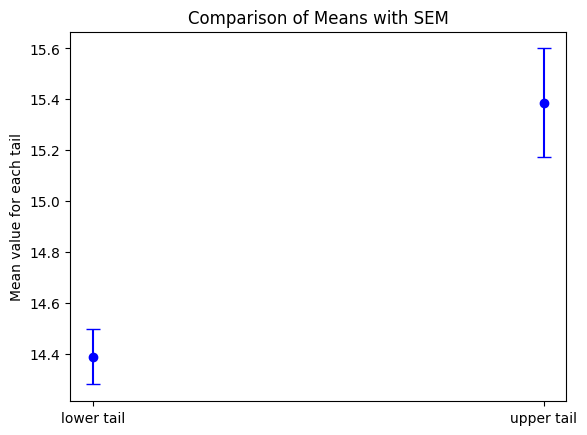

Test for tmax C:  -4.147779118701304
p-value for tmax C:  0.00011443237296293762
 
Conclusion: Reject the null hypothesis (p < alpha),because there is sufficient evidence of a change in tmax C over time. The null hypothesis can be ruled out.
 
###############################################################
 Testing for tmin C
 
mean for lower tail:  6.561036036036036
mean for upper tail:  7.547435897435896
Standard deviation for lower tail:  0.4367566615191821
Standard deviation for upper tail:  1.050193441256219
Variance for lower tail:  0.1907563813813814
Variance for upper tail:  1.1029062640575795
n for lower tail:  37
n for upper tail:  39
Critical value:  2.6439128716530895


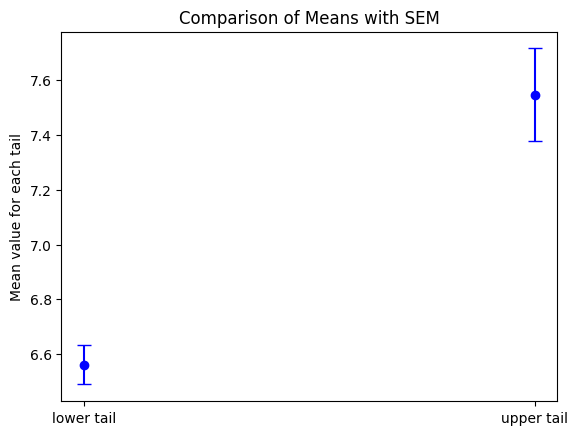

Test for tmin C:  -5.394495972022186
p-value for tmin C:  1.7632662943392899e-06
 
Conclusion: Reject the null hypothesis (p < alpha),because there is sufficient evidence of a change in tmin C over time. The null hypothesis can be ruled out.
 
###############################################################
 Testing for air frost (days)
 
mean for lower tail:  3.4814814814814814
mean for upper tail:  2.596153846153846
Standard deviation for lower tail:  1.115744308321592
Standard deviation for upper tail:  1.5989006710316502
Variance for lower tail:  1.2448853615520281
Variance for upper tail:  2.556483355825461
n for lower tail:  36
n for upper tail:  39
Critical value:  2.644868782073382


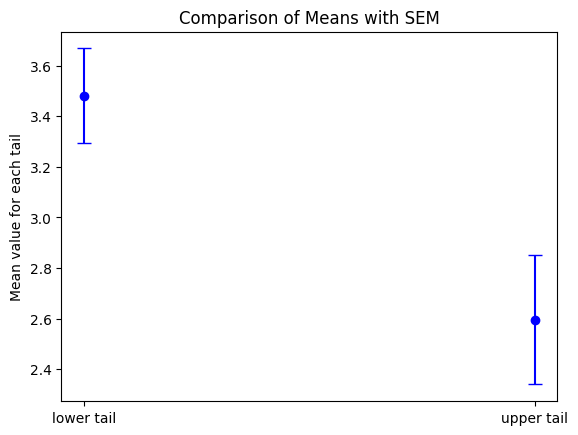

Test for air frost (days):  2.7978197721004294
p-value for air frost (days):  0.006684260645209568
 
Conclusion: Reject the null hypothesis (p < alpha),because there is sufficient evidence of a change in air frost (days) over time. The null hypothesis can be ruled out.
 
###############################################################
 Testing for rain (mm)
 
mean for lower tail:  50.61463963963964
mean for upper tail:  50.93397435897436
Standard deviation for lower tail:  8.028806259907247
Standard deviation for upper tail:  8.767435090858937
Variance for lower tail:  64.46172995912579
Variance for upper tail:  76.86791807242466
n for lower tail:  37
n for upper tail:  39
Critical value:  2.6439128716530895


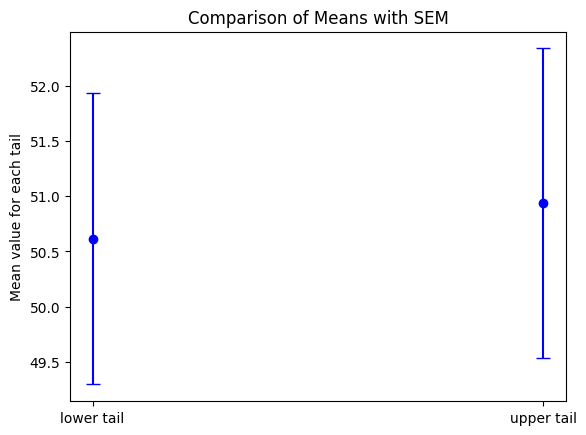

Test for rain (mm):  -0.1657192920200354
p-value for rain (mm):  0.8688303249439978
 
Conclusion: Fail to reject the null hypothesis (p > alpha), because there is insufficient evidence of a change in rain (mm) over time. The null hypothesis cannot be ruled out.
 
###############################################################
 Testing for sun (hours)
 
mean for lower tail:  123.81845238095237
mean for upper tail:  131.21239316239314
Standard deviation for lower tail:  9.682738968696823
Standard deviation for upper tail:  17.13798285688135
Variance for lower tail:  93.75543393592
Variance for upper tail:  293.71045640275906
n for lower tail:  28
n for upper tail:  39
Critical value:  2.653604469382925


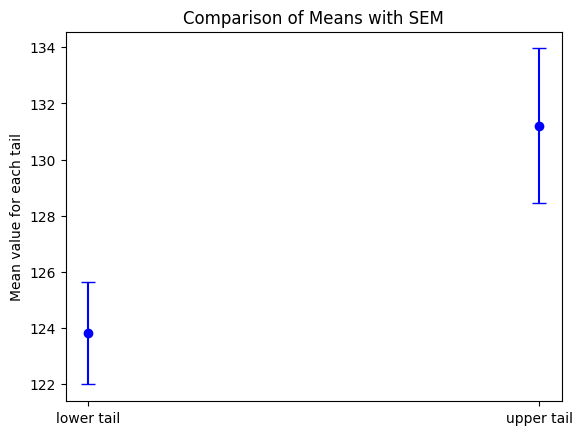

Test for sun (hours):  -2.24167466496923
p-value for sun (hours):  0.028568480015055336
 
Conclusion: Fail to reject the null hypothesis (p > alpha), because there is insufficient evidence of a change in sun (hours) over time. The null hypothesis cannot be ruled out.


In [22]:


def hypotesis_testing(cols):
    change_year = 1985

    for col in cols:
          early_col = annual_avg[annual_avg["yyyy"] < change_year][col].dropna()
          recent_col = annual_avg[annual_avg["yyyy"] >= change_year][col].dropna()
          print(" ")
          print("###############################################################")
          print(f' Testing for {col}')
          print(" ")
        
          ###################################
          mean_early = early_col.mean()    
          mean_recent = recent_col.mean()
          print("mean for lower tail: ",mean_early)
          print("mean for upper tail: ",mean_recent)

          std_early = early_col.std()
          std_recent = recent_col.std()
          print("Standard deviation for lower tail: ",std_early)
          print("Standard deviation for upper tail: ",std_recent)

          var_early = early_col.var()
          var_recent = recent_col.var()
          print("Variance for lower tail: ",var_early)
          print("Variance for upper tail: ",var_recent)

          n_early = len(early_col)
          n_recent = len(recent_col)
          dof = n_early + n_recent - 2
          critical_value = stats.t.ppf(1 - 0.01/2, dof)
          print("n for lower tail: ",n_early)
          print("n for upper tail: ",n_recent)
          print("Critical value: ",critical_value)

          sem_early = std_early / math.sqrt(n_early)
          sem_recent = std_recent / math.sqrt(n_recent)

          plt.errorbar([1943,2023], [mean_early,mean_recent], yerr=[sem_early,sem_recent], fmt="o", capsize=5, color='blue')
          plt.xticks([1943,2023], ["lower tail","upper tail"])
          plt.ylabel("Mean value for each tail")
          plt.title("Comparison of Means with SEM")
          plt.show()
          
            
          ################################################


          t_stat, p_value = ttest_ind(early_col, recent_col, equal_var=False)
          print(f'Test for {col}: ',t_stat)
          print(f'p-value for {col}: ',p_value)
          print(" ")

          alpha_value = 0.01
          if p_value < alpha_value:
               print(f'Conclusion: Reject the null hypothesis (p < alpha),because there is sufficient evidence of a change in {col} over time. The null hypothesis can be ruled out.')
          else:
               print(f'Conclusion: Fail to reject the null hypothesis (p > alpha), because there is insufficient evidence of a change in {col} over time. The null hypothesis cannot be ruled out.')
    


test = hypotesis_testing(cols)



The End